 # Skin Diasese detection test

In [12]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')
tf.test.is_gpu_available()

True

In [14]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [13]:
tf.__version__

'2.10.0'

## Processing

## Model Fine tuning

In [3]:
# Loading the model
from tensorflow.keras.models import load_model
model = load_model('299-model-test-v5.h5')

In [4]:
import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [15]:
# Loading new data
NEW_DATA_DIR = r"C:\Users\User\Downloads\Skin-disease-dataset\new-data"
BATCH_SIZE   = 32
IMG_SIZE     = (224, 224)


new_datagen = ImageDataGenerator(rescale=1./255)

new_data_gen = new_datagen.flow_from_directory(
    NEW_DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)


Found 1205 images belonging to 6 classes.


In [16]:
# Optionally freeze early layers again
base_model = model.layers[0]
for layer in base_model.layers[:-40]:  
    layer.trainable = False

In [17]:
# Fine tune the model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='loss', factor=0.5, patience=2)
]

model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Fine-tune with new data
model.fit(new_data_gen, epochs=5, callbacks=callbacks)


Epoch 1/5
38/38 [==============================] - 6s 81ms/step - loss: 0.0919 - accuracy: 0.9751 - lr: 1.0000e-05
Epoch 2/5
38/38 [==============================] - 3s 66ms/step - loss: 0.0615 - accuracy: 0.9793 - lr: 1.0000e-05
Epoch 3/5
38/38 [==============================] - 3s 65ms/step - loss: 0.0486 - accuracy: 0.9817 - lr: 1.0000e-05
Epoch 4/5
38/38 [==============================] - 3s 66ms/step - loss: 0.0336 - accuracy: 0.9859 - lr: 1.0000e-05
Epoch 5/5
38/38 [==============================] - 2s 62ms/step - loss: 0.0402 - accuracy: 0.9859 - lr: 1.0000e-05


In [ ]:
#model.save('fine_tuned_model_v1.h5')

In [18]:

# Common parameters
BATCH_SIZE   = 32
IMG_SIZE     = (224, 224)
DATA_DIR     = r"C:\Users\User\Downloads\Skin-disease-dataset\train"
SEED         = 42           # keeps split reproducible
VAL_SPLIT    = 0.20         # 80 % train, 20 % validation

datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest',
    validation_split=VAL_SPLIT      # ← **key line**
)



training_set = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',              # ← **80 % of images**
    shuffle=True,
    seed=SEED
)

test_set = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',            # ← **20 % of images**
    shuffle=True,
    seed=SEED
)


Found 38751 images belonging to 6 classes.
Found 9683 images belonging to 6 classes.


In [ ]:
# from tensorflow.keras.models import load_model
# # Load the model
# model = load_model('299-model-test-v5.h5')

1/1 [==============================] - 0s 470ms/step


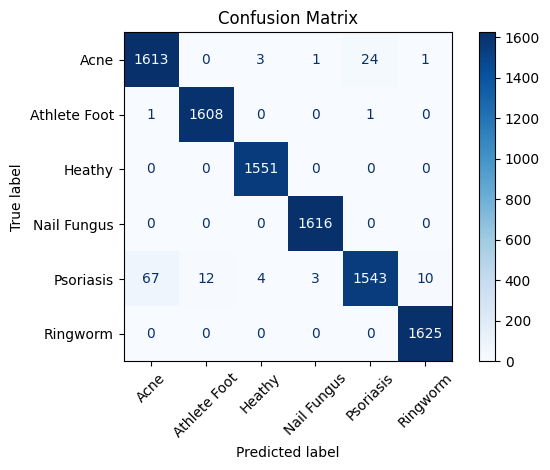

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Get true labels and predictions
Y_true = []
Y_pred = []

# Go through test batches and collect predictions
for i in range(len(test_set)):
    x_batch, y_batch = test_set[i]
    y_pred_batch = model.predict(x_batch)
    
    Y_true.extend(np.argmax(y_batch, axis=1))
    Y_pred.extend(np.argmax(y_pred_batch, axis=1))

    if (i + 1) * test_set.batch_size >= test_set.samples:
        break  # Stop if we've processed all test data

# 2. Compute confusion matrix
cm = confusion_matrix(Y_true, Y_pred)
labels = list(test_set.class_indices.keys())  # Class names

# 3. Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
